In [2]:
import pandas as pd
import numpy as np
import feature_selection as fs
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import matthews_corrcoef
from catboost import CatBoostClassifier
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from ydata_profiling import ProfileReport
import getting_threshold_genes as gtg
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from ydata_profiling import ProfileReport
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import model as m
import catboost_model as miaw

ModuleNotFoundError: No module named 'catboost'

This is to see for the sarcopenia data only

In [2]:
eigth_bins_original = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_test.csv")
eigth_bins_original.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age,Sample,Experiment
0,-0.022199,-0.024329,-0.003773,-0.024342,-0.023168,-0.023118,-0.019650,-0.021929,-0.022809,-0.023842,...,-0.024369,-0.024371,-0.023585,-0.024358,-0.024395,-0.023025,-0.024297,24.0,SRR12604218,GSE157585
1,-0.020040,-0.021205,-0.004026,-0.020311,-0.020125,-0.021354,-0.018610,-0.019685,-0.018587,-0.019628,...,-0.021322,-0.021221,-0.021747,-0.021319,-0.021378,-0.022606,-0.021146,18.0,SRR13759023,GSE167186
2,-0.025774,-0.027019,-0.004049,-0.024784,-0.023620,-0.026312,-0.020406,-0.022771,-0.020741,-0.023250,...,-0.026922,-0.026842,-0.026598,-0.026915,-0.026944,-0.020781,-0.026752,23.0,SRR13759025,GSE167186
3,-0.026286,-0.031094,0.001080,-0.029463,-0.029558,-0.029211,-0.020112,-0.026330,-0.020258,-0.028490,...,-0.030938,-0.030771,-0.028873,-0.030937,-0.030940,-0.030323,-0.030942,26.4,SRR1555206,GSE60590
4,-0.021510,-0.026220,0.001219,-0.022533,-0.023448,-0.025671,-0.014182,-0.018851,-0.015137,-0.019720,...,-0.026261,-0.026039,-0.026443,-0.026252,-0.026286,-0.024934,-0.026092,71.0,SRR12604184,GSE157585


In [3]:
eigth_bins_original=eigth_bins_original[eigth_bins_original["Experiment"]=="GSE167186"]
eigth_bins_original.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age,Sample,Experiment
1,-0.020040,-0.021205,-0.004026,-0.020311,-0.020125,-0.021354,-0.018610,-0.019685,-0.018587,-0.019628,...,-0.021322,-0.021221,-0.021747,-0.021319,-0.021378,-0.022606,-0.021146,18.0,SRR13759023,GSE167186
2,-0.025774,-0.027019,-0.004049,-0.024784,-0.023620,-0.026312,-0.020406,-0.022771,-0.020741,-0.023250,...,-0.026922,-0.026842,-0.026598,-0.026915,-0.026944,-0.020781,-0.026752,23.0,SRR13759025,GSE167186
9,-0.025546,-0.025997,-0.004334,-0.024036,-0.024318,-0.025440,-0.018914,-0.022188,-0.019970,-0.021814,...,-0.025937,-0.025853,-0.025746,-0.025931,-0.025965,-0.028434,-0.025766,92.0,SRR13758994,GSE167186
11,-0.019799,-0.025597,-0.004365,-0.023743,-0.023969,-0.025100,-0.019546,-0.021514,-0.020003,-0.022533,...,-0.025553,-0.024909,-0.025412,-0.025547,-0.025583,-0.026734,-0.025381,84.0,SRR13759029,GSE167186
12,-0.026776,-0.031757,-0.004299,-0.028254,-0.028305,-0.030353,-0.019103,-0.025470,-0.021957,-0.027284,...,-0.031486,-0.031423,-0.030552,-0.031476,-0.031480,-0.028215,-0.031320,74.0,SRR13759002,GSE167186


In [4]:
seq_metadata_path = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/All_rna_samples_metadata_edit.csv"
seq_metadata = pd.read_csv(seq_metadata_path)
rnaSeq_origial= pd.merge(eigth_bins_original, seq_metadata, on='Sample', how='inner')
rnaSeq_origial.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age,Sample,Experiment,Status,Sex
0,-0.020040,-0.021205,-0.004026,-0.020311,-0.020125,-0.021354,-0.018610,-0.019685,-0.018587,-0.019628,...,-0.021747,-0.021319,-0.021378,-0.022606,-0.021146,18.0,SRR13759023,GSE167186,Healthy,NaN
1,-0.025774,-0.027019,-0.004049,-0.024784,-0.023620,-0.026312,-0.020406,-0.022771,-0.020741,-0.023250,...,-0.026598,-0.026915,-0.026944,-0.020781,-0.026752,23.0,SRR13759025,GSE167186,Healthy,NaN
2,-0.025546,-0.025997,-0.004334,-0.024036,-0.024318,-0.025440,-0.018914,-0.022188,-0.019970,-0.021814,...,-0.025746,-0.025931,-0.025965,-0.028434,-0.025766,92.0,SRR13758994,GSE167186,Sarcopenia,NaN
3,-0.019799,-0.025597,-0.004365,-0.023743,-0.023969,-0.025100,-0.019546,-0.021514,-0.020003,-0.022533,...,-0.025412,-0.025547,-0.025583,-0.026734,-0.025381,84.0,SRR13759029,GSE167186,Healthy,male
4,-0.026776,-0.031757,-0.004299,-0.028254,-0.028305,-0.030353,-0.019103,-0.025470,-0.021957,-0.027284,...,-0.030552,-0.031476,-0.031480,-0.028215,-0.031320,74.0,SRR13759002,GSE167186,Sarcopenia,NaN


In [5]:
len(rnaSeq_origial)

32

In [6]:
x_labels= rnaSeq_origial["Status"].value_counts()

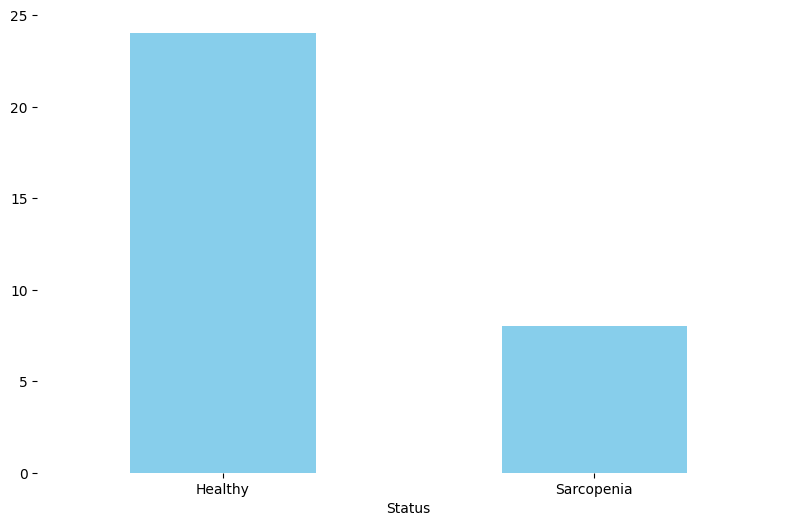

In [7]:
status_counts = rnaSeq_origial["Status"].value_counts()

plt.figure(figsize=(8, 6))
status_counts.plot(kind='bar', color='skyblue')
plt.tight_layout()
plt.box(False)

plt.xticks(rotation=0)
plt.show()

In [1]:
rnaSeq_origial["Age_C"] = np.where(rnaSeq_origial["Age"] > 65, "Old", "Young")
rnaSeq_origial["Class"]=rnaSeq_origial["Status"].astype(str) +" "+ rnaSeq_origial["Age_C"].astype(str)




NameError: name 'np' is not defined

In [2]:
status_counts = rnaSeq_origial["Status"].value_counts()

plt.figure(figsize=(8, 6))
status_counts.plot(kind='bar', color='skyblue')
plt.tight_layout()
plt.box(False)

plt.xticks(rotation=0)
plt.show()

NameError: name 'rnaSeq_origial' is not defined

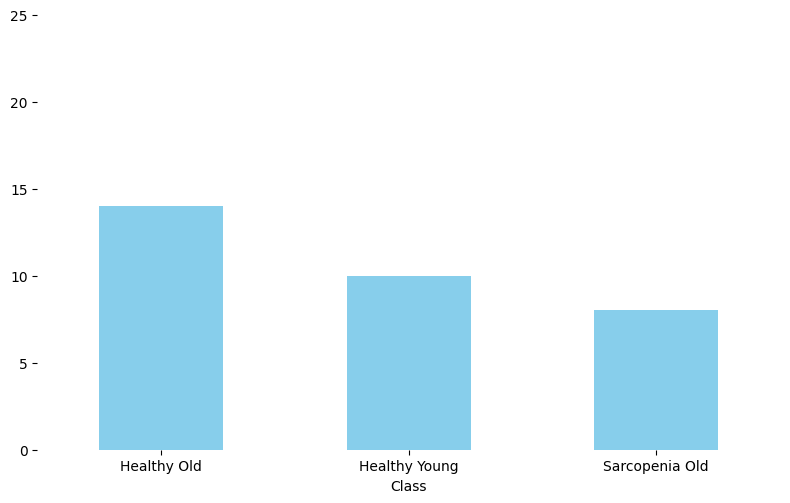

In [9]:
status_counts = rnaSeq_origial["Class"].value_counts()

plt.figure(figsize=(8, 6))
status_counts.plot(kind='bar', color='skyblue')
plt.tight_layout()
plt.box(False)
plt.ylim(0, 25)
plt.xticks(rotation=0)
plt.show()

In [10]:
remove_youn = rnaSeq_origial[rnaSeq_origial["Age_C"]=="Old"]

In [11]:
seq_X_train, seq_X_test, seq_y_train, seq_y_test, seq_z_train, seq_z_test = train_test_split(remove_youn.drop(["Sample", "Status", "Age","Sex", "Age_C", "Class", "Experiment"], axis=1), remove_youn["Status"], remove_youn["Age"], test_size=0.1, random_state=42)


In [45]:
len(seq_X_train), len(seq_X_test)

(19, 3)

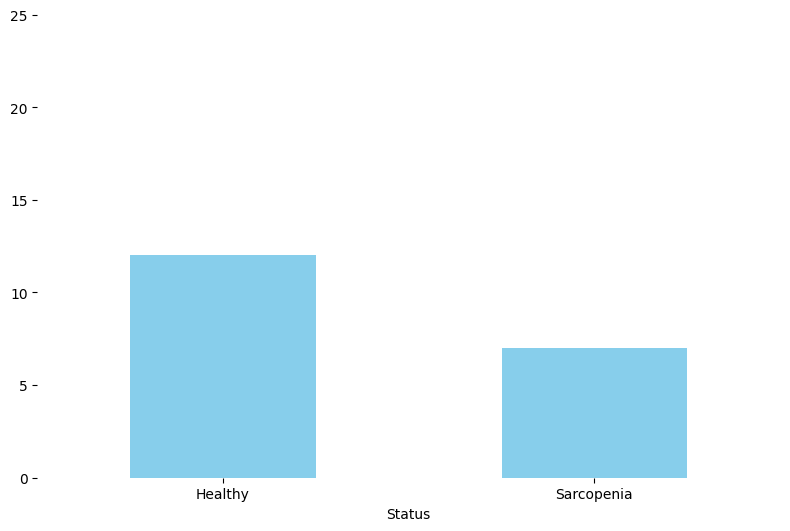

In [46]:
status_counts = seq_y_train.value_counts()

plt.figure(figsize=(8, 6))
status_counts.plot(kind='bar', color='skyblue')
plt.tight_layout()
plt.box(False)
plt.ylim(0, 25)
plt.xticks(rotation=0)
plt.show()

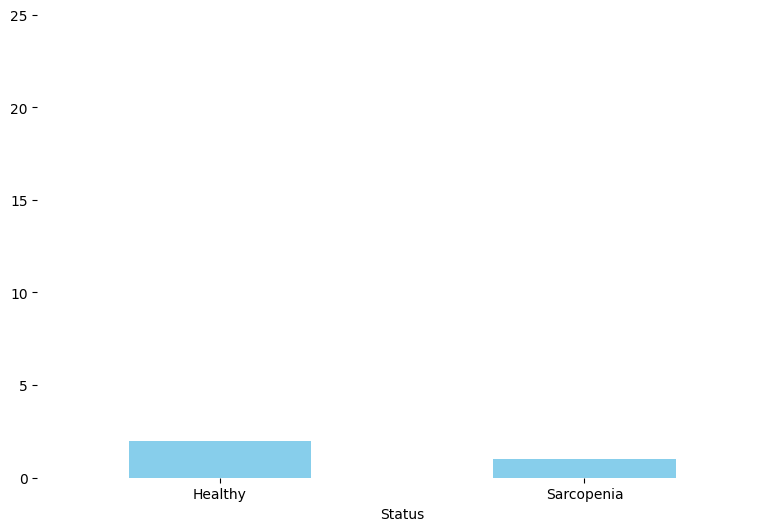

In [47]:
status_counts = seq_y_test.value_counts()

plt.figure(figsize=(8, 6))
status_counts.plot(kind='bar', color='skyblue')
plt.tight_layout()
plt.box(False)
plt.ylim(0, 25)
plt.xticks(rotation=0)
plt.show()

In [48]:
train_df = pd.concat([seq_X_train, seq_y_train], axis=1)
train_df.columns=seq_X_train.columns.tolist()+["Age"]
train_df.head()

,ENSG00000232177.1,ENSG00000189058.8,ENSG00000249072.1,ENSG00000127720.7,ENSG00000270388.1,ENSG00000255633.5,ENSG00000233494.1,ENSG00000199455.1,ENSG00000185885.15,ENSG00000255823.4,...,ENSG00000185915.5,ENSG00000108946.14,ENSG00000197872.11,ENSG00000140795.12,ENSG00000133315.10,ENSG00000112562.18,ENSG00000146574.15,ENSG00000202430.1,ENSG00000107959.15,Age
3,-0.015123,-0.016370,-0.010111,-0.016588,-0.021228,-0.025683,-0.021796,-0.023044,-0.023337,33.487182,...,-0.012272,0.043281,-0.022522,-0.004317,0.016790,-0.008085,-0.006300,-0.015505,-0.011669,Healthy
22,-0.016632,-0.016428,-0.020206,-0.015173,-0.021293,-0.025869,-0.021890,-0.023117,-0.023455,37.847827,...,-0.012124,0.043968,-0.022536,-0.007045,0.029238,-0.006437,0.003391,-0.015564,-0.009949,Healthy
8,-0.014232,-0.015799,-0.008791,-0.013899,-0.021874,-0.027526,-0.022720,-0.023767,-0.024508,37.507585,...,-0.014183,0.043767,-0.026767,-0.004184,0.013173,-0.010068,-0.011540,-0.016093,-0.013447,Healthy
29,-0.017384,-0.016298,-0.008494,-0.017661,-0.020718,-0.025457,-0.021683,-0.022955,-0.023194,38.853281,...,-0.016285,0.044131,-0.020212,-0.005067,0.023459,-0.007426,0.000595,-0.015432,-0.013524,Healthy
17,-0.015999,-0.014992,-0.009325,-0.015063,-0.019698,-0.021314,-0.019606,-0.021329,-0.020562,40.651064,...,-0.014133,0.042809,-0.017955,-0.005924,0.017933,-0.009284,-0.011559,-0.014109,-0.012818,Healthy


In [49]:
smote = fs.get_feature_SMOTE(train_df, is_categorical=True)


Class distribution before SMOTE: Counter({'Healthy': 12, 'Sarcopenia': 7})
Class distribution after SMOTE: Counter({'Healthy': 12, 'Sarcopenia': 12})


In [50]:

train_df.head()

,ENSG00000232177.1,ENSG00000189058.8,ENSG00000249072.1,ENSG00000127720.7,ENSG00000270388.1,ENSG00000255633.5,ENSG00000233494.1,ENSG00000199455.1,ENSG00000185885.15,ENSG00000255823.4,...,ENSG00000185915.5,ENSG00000108946.14,ENSG00000197872.11,ENSG00000140795.12,ENSG00000133315.10,ENSG00000112562.18,ENSG00000146574.15,ENSG00000202430.1,ENSG00000107959.15,Age
3,-0.015123,-0.016370,-0.010111,-0.016588,-0.021228,-0.025683,-0.021796,-0.023044,-0.023337,33.487182,...,-0.012272,0.043281,-0.022522,-0.004317,0.016790,-0.008085,-0.006300,-0.015505,-0.011669,Healthy
22,-0.016632,-0.016428,-0.020206,-0.015173,-0.021293,-0.025869,-0.021890,-0.023117,-0.023455,37.847827,...,-0.012124,0.043968,-0.022536,-0.007045,0.029238,-0.006437,0.003391,-0.015564,-0.009949,Healthy
8,-0.014232,-0.015799,-0.008791,-0.013899,-0.021874,-0.027526,-0.022720,-0.023767,-0.024508,37.507585,...,-0.014183,0.043767,-0.026767,-0.004184,0.013173,-0.010068,-0.011540,-0.016093,-0.013447,Healthy
29,-0.017384,-0.016298,-0.008494,-0.017661,-0.020718,-0.025457,-0.021683,-0.022955,-0.023194,38.853281,...,-0.016285,0.044131,-0.020212,-0.005067,0.023459,-0.007426,0.000595,-0.015432,-0.013524,Healthy
17,-0.015999,-0.014992,-0.009325,-0.015063,-0.019698,-0.021314,-0.019606,-0.021329,-0.020562,40.651064,...,-0.014133,0.042809,-0.017955,-0.005924,0.017933,-0.009284,-0.011559,-0.014109,-0.012818,Healthy


In [51]:
#train_df["Age"]=smote[1]
train_df["Age"] = train_df["Age"].map({"Healthy": 0, "Sarcopenia": 1})


In [52]:
train_df.head()

,ENSG00000232177.1,ENSG00000189058.8,ENSG00000249072.1,ENSG00000127720.7,ENSG00000270388.1,ENSG00000255633.5,ENSG00000233494.1,ENSG00000199455.1,ENSG00000185885.15,ENSG00000255823.4,...,ENSG00000185915.5,ENSG00000108946.14,ENSG00000197872.11,ENSG00000140795.12,ENSG00000133315.10,ENSG00000112562.18,ENSG00000146574.15,ENSG00000202430.1,ENSG00000107959.15,Age
3,-0.015123,-0.016370,-0.010111,-0.016588,-0.021228,-0.025683,-0.021796,-0.023044,-0.023337,33.487182,...,-0.012272,0.043281,-0.022522,-0.004317,0.016790,-0.008085,-0.006300,-0.015505,-0.011669,0
22,-0.016632,-0.016428,-0.020206,-0.015173,-0.021293,-0.025869,-0.021890,-0.023117,-0.023455,37.847827,...,-0.012124,0.043968,-0.022536,-0.007045,0.029238,-0.006437,0.003391,-0.015564,-0.009949,0
8,-0.014232,-0.015799,-0.008791,-0.013899,-0.021874,-0.027526,-0.022720,-0.023767,-0.024508,37.507585,...,-0.014183,0.043767,-0.026767,-0.004184,0.013173,-0.010068,-0.011540,-0.016093,-0.013447,0
29,-0.017384,-0.016298,-0.008494,-0.017661,-0.020718,-0.025457,-0.021683,-0.022955,-0.023194,38.853281,...,-0.016285,0.044131,-0.020212,-0.005067,0.023459,-0.007426,0.000595,-0.015432,-0.013524,0
17,-0.015999,-0.014992,-0.009325,-0.015063,-0.019698,-0.021314,-0.019606,-0.021329,-0.020562,40.651064,...,-0.014133,0.042809,-0.017955,-0.005924,0.017933,-0.009284,-0.011559,-0.014109,-0.012818,0


In [53]:
params_c = miaw.optimize_data_classification(train_df)


[I 2024-05-15 13:22:05,562] A new study created in memory with name: no-name-374e24e1-f8dd-42c3-8739-311a119830b2
[I 2024-05-15 13:22:05,726] Trial 0 finished with value: 0.75 and parameters: {'iterations': 221, 'learning_rate': 0.0075963188905459975, 'depth': 4, 'l2_leaf_reg': 1.355576692519438}. Best is trial 0 with value: 0.75.
[I 2024-05-15 13:22:05,888] Trial 1 finished with value: 0.75 and parameters: {'iterations': 457, 'learning_rate': 0.008544851950355863, 'depth': 4, 'l2_leaf_reg': 7.2955120482179945}. Best is trial 0 with value: 0.75.
[I 2024-05-15 13:22:06,059] Trial 2 finished with value: 0.5 and parameters: {'iterations': 294, 'learning_rate': 0.002915026455011116, 'depth': 2, 'l2_leaf_reg': 4.595872466007366}. Best is trial 0 with value: 0.75.
[I 2024-05-15 13:22:06,177] Trial 3 finished with value: 0.75 and parameters: {'iterations': 139, 'learning_rate': 0.0063583829242526, 'depth': 3, 'l2_leaf_reg': 6.331029874349294}. Best is trial 0 with value: 0.75.
[I 2024-05-15 1

In [54]:
params = {'iterations': 167, 'learning_rate': 0.003873552369834775, 'depth': 3, 'loss_function': 'Logloss'}

In [56]:
X = seq_X_train
y = seq_y_train
classifier = CatBoostClassifier(iterations=150,  # Number of boosting iterations
                              learning_rate=0.05,  # Learning rate
                              depth=5,  # Depth of trees
                              random_state=42,  # Random seed for reproducibility
                              verbose=1)  # Verbosity level (0 - silent, 1 - verbose)

# Fit the model
classifier.fit(X, y, eval_set=(seq_X_test,seq_y_test),use_best_model=True, plot=True)



MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6505255	test: 0.6722704	best: 0.6722704 (0)	total: 3.08ms	remaining: 459ms
1:	learn: 0.6226389	test: 0.6861525	best: 0.6722704 (0)	total: 6.08ms	remaining: 450ms
2:	learn: 0.5914106	test: 0.6872737	best: 0.6722704 (0)	total: 8.67ms	remaining: 425ms
3:	learn: 0.5570694	test: 0.6771863	best: 0.6722704 (0)	total: 10.9ms	remaining: 396ms
4:	learn: 0.5338203	test: 0.6696966	best: 0.6696966 (4)	total: 14.7ms	remaining: 426ms
5:	learn: 0.4959969	test: 0.6235606	best: 0.6235606 (5)	total: 18.2ms	remaining: 437ms
6:	learn: 0.4647108	test: 0.6183737	best: 0.6183737 (6)	total: 20.5ms	remaining: 418ms
7:	learn: 0.4436415	test: 0.6165257	best: 0.6165257 (7)	total: 22.7ms	remaining: 402ms
8:	learn: 0.4201458	test: 0.5940259	best: 0.5940259 (8)	total: 24.7ms	remaining: 387ms
9:	learn: 0.4059608	test: 0.5972703	best: 0.5940259 (8)	total: 27.2ms	remaining: 381ms
10:	learn: 0.3860399	test: 0.6108009	best: 0.5940259 (8)	total: 30.1ms	remaining: 380ms
11:	learn: 0.3698676	test: 0.6130494	best:

In [23]:
from catboost import Pool, cv


In [57]:
# Make predictions
y_pred = classifier.predict(seq_X_test)
seq_y_test = seq_y_test.map({"Healthy": 0, "Sarcopenia": 1})
seq_auc = accuracy_score(seq_y_test, y_pred)
seq_results = pd.DataFrame({'Actual': seq_y_test, 'Predicted': y_pred})
seq_auc

TypeError: Labels in y_true and y_pred should be of the same type. Got y_true=[0 1] and y_pred=['Healthy']. Make sure that the predictions provided by the classifier coincides with the true labels.

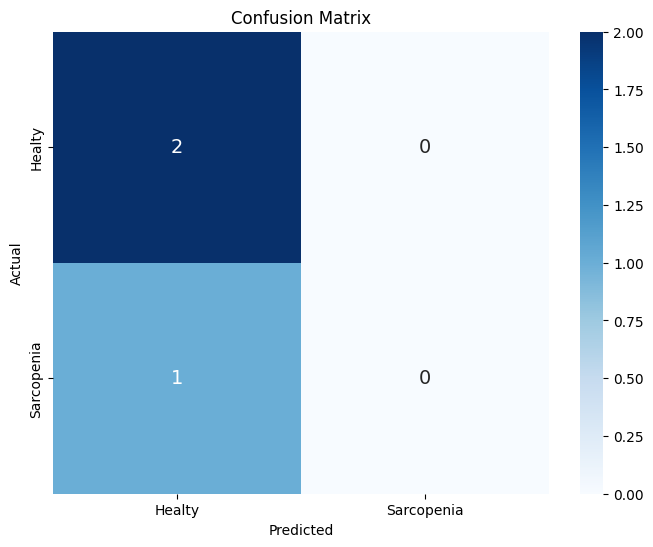

In [25]:
conf_matrix = confusion_matrix(seq_y_test, y_pred)

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
            xticklabels=["Healty", "Sarcopenia"], yticklabels=["Healty", "Sarcopenia"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [58]:
from catboost import CatBoostClassifier, Pool, cv
from sklearn.metrics import roc_auc_score
import numpy as np

# Define Pool for train data
train_pool = Pool(data=X, label=y)

# Define CatBoost model with loss function
model_params = params
model_params['loss_function'] = 'Logloss'

# Perform cross-validation
cv_results = cv(train_pool, model_params, fold_count=3, plot=True, stratified=True, partition_random_seed=42, shuffle=True, metric_period=1)

# Retrieve best iteration
best_iteration = np.argmin(cv_results['test-Logloss-mean'])  # Finding the index of the minimum mean Logloss
print("Best Iteration:", best_iteration)

# Train model with best iteration
best_model = CatBoostClassifier(iterations=best_iteration, depth=6, learning_rate=0.1, loss_function='Logloss')
best_model.fit(X, y)

# Make predictions
predictions = best_model.predict(seq_X_test)

# Evaluate model
auc = roc_auc_score(seq_y_test, predictions)
print("AUC:", auc)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training on fold [0/3]
0:	learn: 0.6906847	test: 0.6927958	best: 0.6927958 (0)	total: 2.6ms	remaining: 431ms
1:	learn: 0.6866864	test: 0.6913408	best: 0.6913408 (1)	total: 4.07ms	remaining: 336ms
2:	learn: 0.6824440	test: 0.6906618	best: 0.6906618 (2)	total: 5.78ms	remaining: 316ms
3:	learn: 0.6794608	test: 0.6896836	best: 0.6896836 (3)	total: 7.34ms	remaining: 299ms
4:	learn: 0.6759644	test: 0.6880159	best: 0.6880159 (4)	total: 8.56ms	remaining: 277ms
5:	learn: 0.6721568	test: 0.6866674	best: 0.6866674 (5)	total: 11.4ms	remaining: 307ms
6:	learn: 0.6689663	test: 0.6859980	best: 0.6859980 (6)	total: 13.5ms	remaining: 309ms
7:	learn: 0.6648145	test: 0.6850670	best: 0.6850670 (7)	total: 14.8ms	remaining: 294ms
8:	learn: 0.6612670	test: 0.6838176	best: 0.6838176 (8)	total: 16ms	remaining: 280ms
9:	learn: 0.6591431	test: 0.6833282	best: 0.6833282 (9)	total: 17.4ms	remaining: 273ms
10:	learn: 0.6556354	test: 0.6825636	best: 0.6825636 (10)	total: 18.7ms	remaining: 265ms
11:	learn: 0.6517678	

ValueError: could not convert string to float: 'Healthy'

In [59]:
predictions = best_model.predict(seq_X_test)

# Evaluate model
auc = roc_auc_score(seq_y_test, predictions)

ValueError: could not convert string to float: 'Healthy'

In [61]:
predictions

array(['Healthy', 'Healthy', 'Healthy'], dtype=object)

In [29]:
training_predictions = best_model.predict(X)
training_auc = roc_auc_score(y, training_predictions)
training_auc


1.0

In [30]:
from sklearn.metrics import confusion_matrix


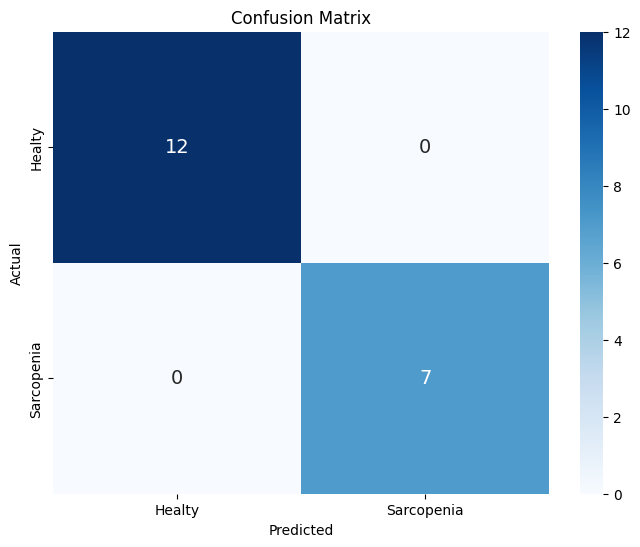

In [31]:
training_predictions = best_model.predict(X)
training_auc = roc_auc_score(y, training_predictions)
training_auc
conf_matrix = confusion_matrix(y, training_predictions)

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
            xticklabels=["Healty", "Sarcopenia"], yticklabels=["Healty", "Sarcopenia"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

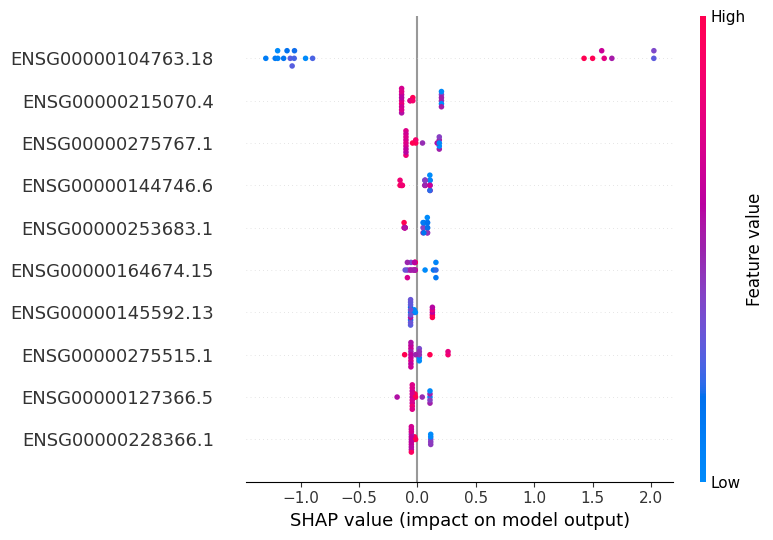

In [32]:
explainer = shap.Explainer(best_model)
shap_values = explainer.shap_values(X)
importance = best_model.get_feature_importance()
feature_imporance_df = pd.DataFrame(importance, index=X.columns, columns=["importance"])
feature_imporance_df=feature_imporance_df[feature_imporance_df["importance"] > 0]
feature_imporance_df = feature_imporance_df.sort_values(by="importance", ascending=False)
gene_names = [
("ENSG00000101892.11","ATP1B4"),
("ENSG00000201766.1","RNA5SP302"),
("ENSG00000127241.16","MASP1"),
("ENSG00000277654.5","AC087633.2"),
("ENSG00000145949.10","MYLK4"),
("ENSG00000171055.14","FEZ2"),
("ENSG00000198712.1","MT-CO2"),
("ENSG00000164104.11","HMGB2"),
("ENSG00000172399.5","MYOZ2"),
("ENSG00000177548.12","RABEP2"),
("ENSG00000089101.17","CFAP61"),
("ENSG00000003989.17","SLC7A2"),
("ENSG00000137700.17","SLC37A4"),
("ENSG00000174227.15","PIGG"),
("ENSG00000133020.4","MYH8"),
("ENSG00000252262.1","RNA5SP61"),
("ENSG00000234441.1","AC105272.1"),
("ENSG00000247627.2","MTND4P12"),
("ENSG00000100568.10","VTI1B"),
("ENSG00000237973.1","MTCO1P12"),
("ENSG00000170873.18","MTSS1"),
("ENSG00000082397.17"	,"EPB41L3"),
("ENSG00000111640.14"	,"GAPDH")
]

for gene_id, gene_name in gene_names:
    if gene_id in X.columns:
        X.rename(columns={gene_id: gene_name}, inplace=True)

shap.summary_plot(shap_values, X, max_display=10)


In [33]:
best_model.classes_

array([0, 1])

In [34]:
feature_imporance_df.head(50)

,importance
ENSG00000104763.18,10.627728
ENSG00000215070.4,10.250466
ENSG00000275515.1,8.216039
ENSG00000149782.11,3.328963
ENSG00000186318.16,2.975507
ENSG00000284620.1,2.955468
ENSG00000164074.15,2.887920
ENSG00000145592.13,2.859833
ENSG00000117616.17,2.372014
ENSG00000228366.1,2.256285


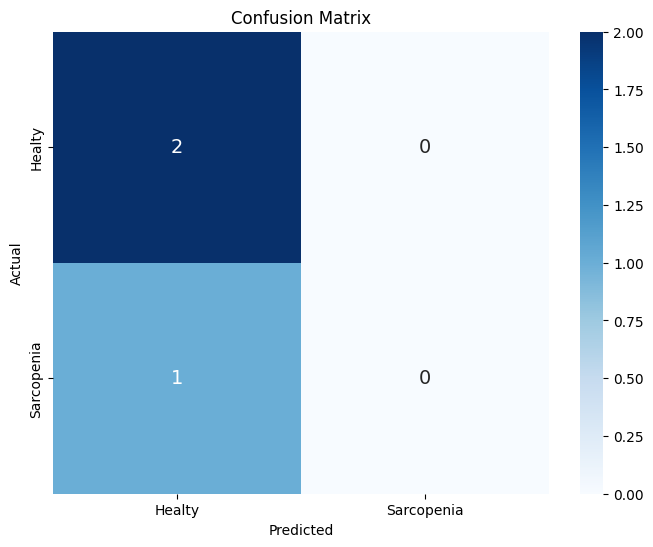

In [35]:
seq_y_test_map = seq_y_test.copy()

test_predictions = best_model.predict(seq_X_test)
test_auc = roc_auc_score(seq_y_test_map, test_predictions)
test_auc
conf_matrix = confusion_matrix(seq_y_test_map, test_predictions)

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
            xticklabels=["Healty", "Sarcopenia"], yticklabels=["Healty", "Sarcopenia"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [36]:
seq_y_test

2     1
20    0
13    0
Name: Status, dtype: int64

## Using pre selected genes

In [42]:
ridge_selection = f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/feature_selection/RNAs_z_Combat_feature_selection.csv"
df = gtg.get_df(ridge_selection)# alpha=0.05
rnaseq_genes = df["Ensembl"]
len(rnaseq_genes)

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
0.1450134054998397


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/pandas/core/indexes/base.py:945: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*new_inputs, **kwargs)
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/numpy/lib/polynomial.py:668: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


458

In [43]:
rnaseq_genes = rnaseq_genes.to_list()

rnaseq_genes.append("Status")
eigth_bins_filteres = remove_youn[rnaseq_genes]
eigth_bins_filteres.head()


,ENSG00000232177.1,ENSG00000189058.8,ENSG00000249072.1,ENSG00000127720.7,ENSG00000270388.1,ENSG00000255633.5,ENSG00000233494.1,ENSG00000199455.1,ENSG00000185885.15,ENSG00000255823.4,...,ENSG00000185915.5,ENSG00000108946.14,ENSG00000197872.11,ENSG00000140795.12,ENSG00000133315.10,ENSG00000112562.18,ENSG00000146574.15,ENSG00000202430.1,ENSG00000107959.15,Status
2,-0.017537,-0.016442,-0.020223,-0.015611,-0.020739,-0.025913,-0.021912,-0.023134,-0.023483,39.006978,...,-0.015750,0.043591,-0.022952,-0.004546,0.019590,-0.010067,-0.007596,-0.015578,-0.013415,Sarcopenia
3,-0.015123,-0.016370,-0.010111,-0.016588,-0.021228,-0.025683,-0.021796,-0.023044,-0.023337,33.487182,...,-0.012272,0.043281,-0.022522,-0.004317,0.016790,-0.008085,-0.006300,-0.015505,-0.011669,Healthy
4,-0.017853,-0.017489,-0.021441,-0.015445,-0.021452,-0.029232,-0.023575,-0.024436,-0.025591,29.373376,...,-0.016880,0.045053,-0.027666,-0.001632,0.017352,-0.008086,-0.006802,-0.016638,-0.012242,Sarcopenia
5,-0.020560,-0.019294,-0.023542,-0.018742,-0.024476,-0.034956,-0.026445,-0.026683,-0.029228,31.784578,...,-0.009802,0.047065,-0.019417,-0.008476,0.038049,-0.009108,-0.003378,-0.018466,-0.009441,Sarcopenia
6,-0.016888,-0.015830,-0.009748,-0.015138,-0.020629,-0.023973,-0.020939,-0.022372,-0.022251,34.607249,...,-0.016417,0.041238,-0.020496,-0.006331,0.021750,-0.008448,-0.011552,-0.014958,-0.013845,Sarcopenia


In [44]:
seq_X_train, seq_X_test, seq_y_train, seq_y_test, seq_z_train, seq_z_test = train_test_split(eigth_bins_filteres.drop(["Status"], axis=1), eigth_bins_filteres["Status"], remove_youn["Status"], test_size=0.1, random_state=42)
